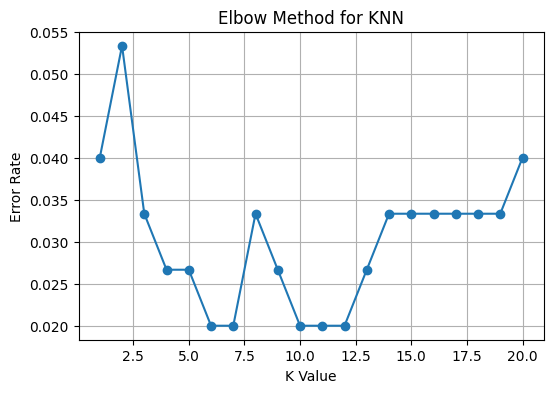

Test Accuracy: 1.0
Cross-validation scores: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Mean CV Accuracy: 0.9666666666666668


In [1]:
# Import libraries
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Load Iris dataset from seaborn
iris = sns.load_dataset("iris")

# Features and target
X = iris.drop("species", axis=1)
y = iris["species"]

# Convert labels to numbers
le = LabelEncoder()
y = le.fit_transform(y)

# -------------------------------
# Elbow Method (Choosing Best K)
# -------------------------------
error_rates = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5)
    error_rates.append(1 - scores.mean())

# Plot
plt.figure(figsize=(6, 4))
plt.plot(range(1, 21), error_rates, marker="o")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.title("Elbow Method for KNN")
plt.grid(True)
plt.show()

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train KNN with chosen K (example: 3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# -------------------------------
# 5-Fold Cross Validation
# -------------------------------
cv_scores = cross_val_score(knn, X, y, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

In [2]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

cv_scores = cross_val_score(knn, X, y, cv=5)
print("Mean CV Accuracy:", cv_scores.mean())

Test Accuracy: 0.9666666666666667
Mean CV Accuracy: 0.9800000000000001


Enter Sepal Length: 1.1
Enter Sepal Width: 0.3
Enter Petal Length: 0.7
Enter Petal Width: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Predicted Species: setosa


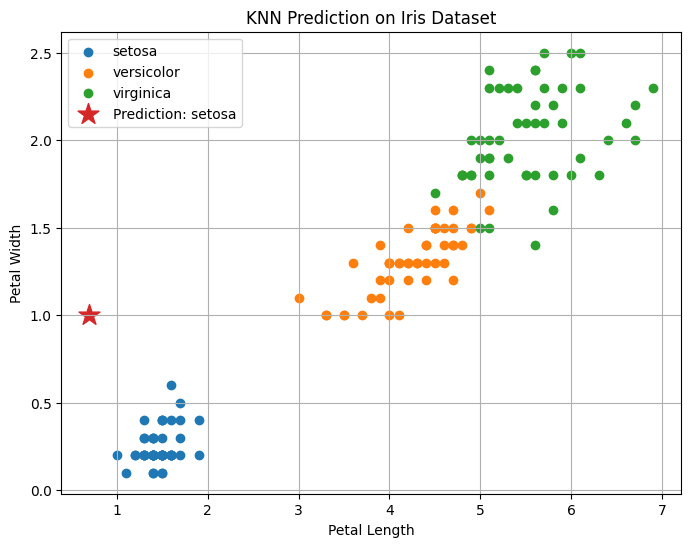

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

# Load Iris dataset
iris = sns.load_dataset("iris")

# Features and target
X = iris.drop("species", axis=1)
y = iris["species"]

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X, y)

# -----------------------------
# Take input from the user
# -----------------------------
sepal_length = float(input("Enter Sepal Length: "))
sepal_width = float(input("Enter Sepal Width: "))
petal_length = float(input("Enter Petal Length: "))
petal_width = float(input("Enter Petal Width: "))

new_flower = [[
    sepal_length,
    sepal_width,
    petal_length,
    petal_width
]]

# Predict
prediction = knn.predict(new_flower)[0]
species = le.inverse_transform([prediction])[0]

print("Predicted Species:", species)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 6))

# Plot existing data (Petal Length vs Petal Width)
for sp in iris["species"].unique():
    subset = iris[iris["species"] == sp]
    plt.scatter(
        subset["petal_length"],
        subset["petal_width"],
        label=sp
    )

# Plot the user's point
plt.scatter(
    petal_length,
    petal_width,
    marker="*",
    s=250,
    label=f"Prediction: {species}"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("KNN Prediction on Iris Dataset")
plt.legend()
plt.grid(True)
plt.show()